In [1]:
# qqp_02.ipynb — Análisis nacional QQP
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sina.db.repository import QQPRepository

# Cargar TODOS los datos de la tabla
repo = QQPRepository()

# Necesitamos un método que jale todo, no solo por municipio
# Opción A: query directo con SQLAlchemy
from sqlalchemy import select
from sina.db.models import PrecioQQP

with repo.Session() as session:
    stmt = select(PrecioQQP)
    rows = session.execute(stmt).scalars().all()
    data = [
        {
            "producto":         r.producto,
            "presentacion":     r.presentacion,
            "marca":            r.marca,
            "categoria":        r.categoria,
            "precio":           r.precio,
            "fecha_registro":   r.fecha_registro,
            "cadena_comercial": r.cadena_comercial,
            "nombre_comercial": r.nombre_comercial,
            "direccion":        r.direccion,
            "estado":           r.estado,
            "municipio":        r.municipio,
            "latitud":          r.latitud,
            "longitud":         r.longitud,
        }
        for r in rows
    ]

df = pd.DataFrame(data)
df['precio'] = df['precio'].astype(float)
print(f"Total registros: {len(df):,}")
print(f"Estados: {df['estado'].nunique()}")
print(f"Municipios: {df['municipio'].nunique()}")
print(f"Combinaciones estado-municipio: {df.groupby(['estado','municipio']).ngroups}")

🗄️  Usando SQLite local: C:\Users\PANDA\Documents\GitHub\sina\datos\db\sina_data.db
Total registros: 549,936
Estados: 30
Municipios: 70
Combinaciones estado-municipio: 72


In [2]:
# Mapa de cobertura: ¿cuántos registros por estado?
estado_stats = df.groupby('estado').agg(
    n_registros=('precio', 'count'),
    n_municipios=('municipio', 'nunique'),
    n_cadenas=('cadena_comercial', 'nunique'),
    n_productos=('producto', 'nunique'),
    n_categorias=('categoria', 'nunique'),
).sort_values('n_registros', ascending=False)

print(f"\n{'='*80}")
print(f"COBERTURA POR ESTADO")
print(f"{'='*80}")
print(estado_stats.to_string())
print(f"\nEstados con datos: {len(estado_stats)}/32")


COBERTURA POR ESTADO
                     n_registros  n_municipios  n_cadenas  n_productos  n_categorias
estado                                                                              
Ciudad de Mexico          135274            13         43          739            44
Estado de Mexico           81691            16         42          742            44
Guanajuato                 27213             1         36          720            42
Jalisco                    22749             4         36          709            43
Tabasco                    22639             1         29          708            41
Chihuahua                  20943             2         28          699            43
Nuevo Leon                 17193             4         32          725            43
Campeche                   14470             1         23          697            41
Baja California Sur        13385             1         25          680            41
Chiapas                    12938           

In [3]:
# Detalle municipios por estado
muni_stats = df.groupby(['estado', 'municipio']).agg(
    n_registros=('precio', 'count'),
    n_cadenas=('cadena_comercial', 'nunique'),
    n_productos=('producto', 'nunique'),
).reset_index().sort_values(['estado', 'n_registros'], ascending=[True, False])

# ¿Cuántos municipios por estado?
muni_por_estado = muni_stats.groupby('estado')['municipio'].count().sort_values(ascending=False)
print(f"\nMunicipios por estado:")
print(muni_por_estado.to_string())
print(f"\nTotal municipios únicos: {muni_stats['municipio'].nunique()}")


Municipios por estado:
estado
Estado de Mexico       16
Ciudad de Mexico       13
Jalisco                 4
Nuevo Leon              4
Oaxaca                  3
Tamaulipas              3
Zacatecas               2
Hidalgo                 2
Veracruz                2
Tlaxcala                2
Chihuahua               2
Campeche                1
Chiapas                 1
Aguascalientes          1
Guanajuato              1
Guerrero                1
Coahuila                1
Durango                 1
Baja California         1
Baja California Sur     1
Morelos                 1
Michoacan               1
San Luis Potosi         1
Quintana Roo            1
Queretaro               1
Puebla                  1
Tabasco                 1
Sonora                  1
Sinaloa                 1
Yucatan                 1

Total municipios únicos: 70


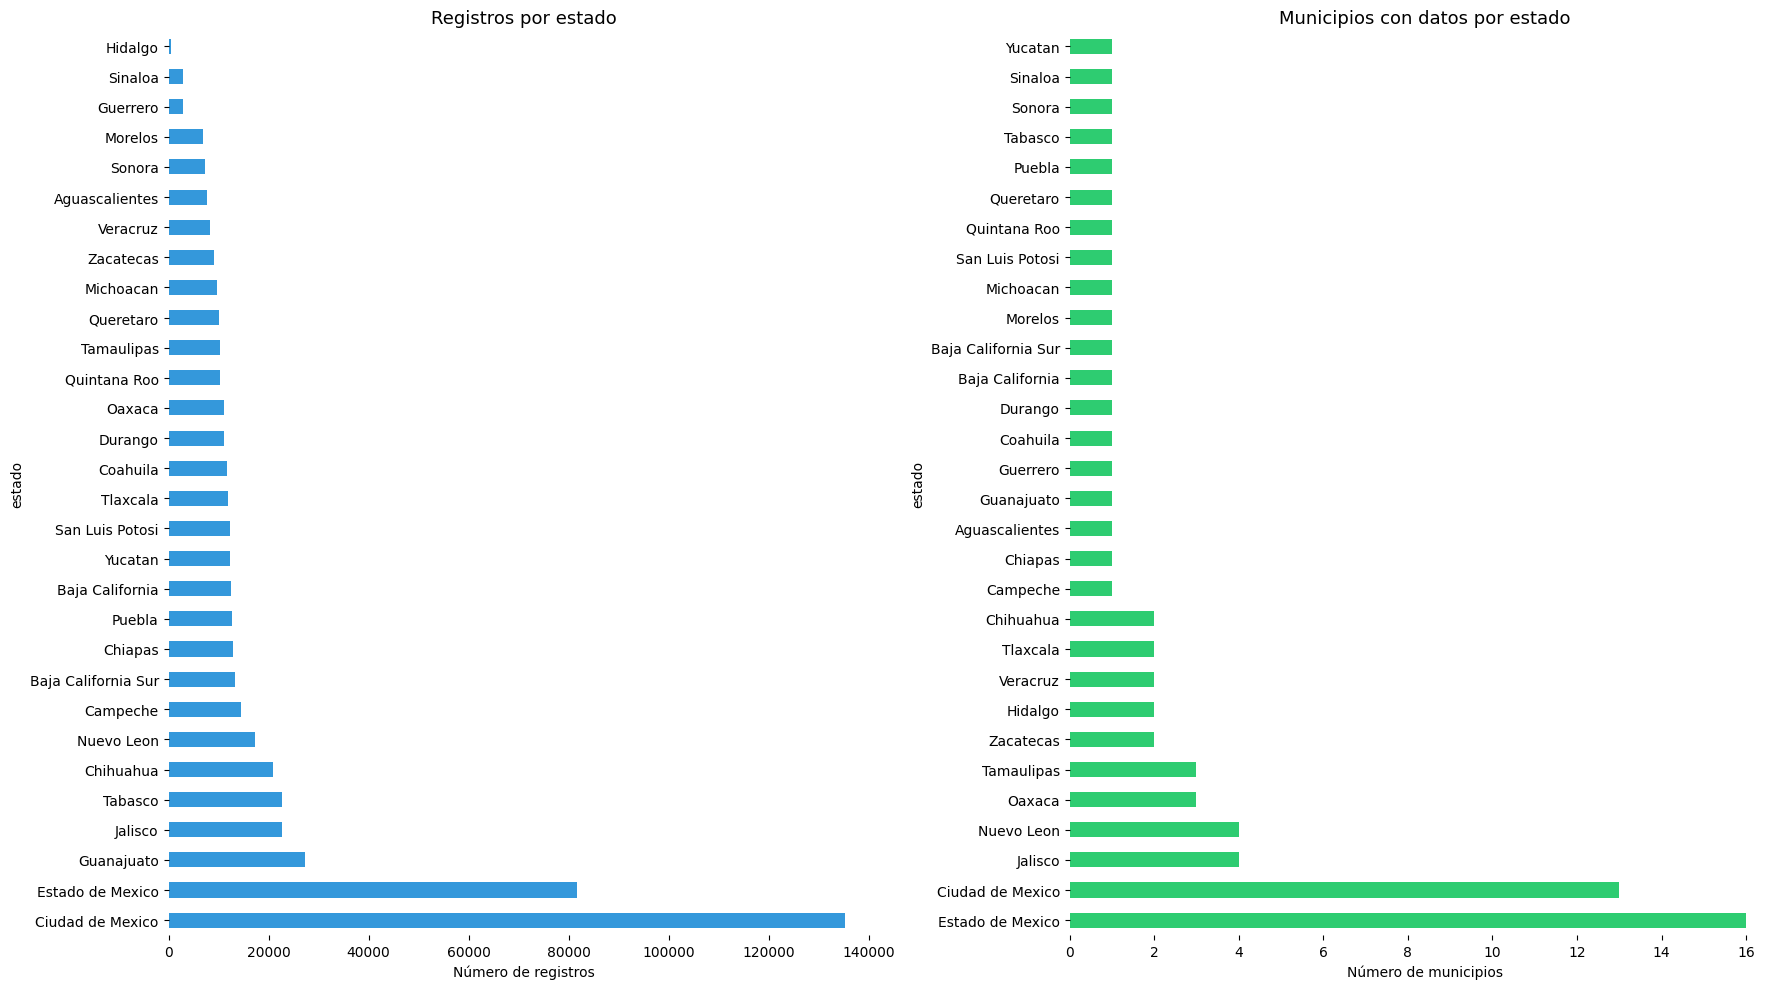

In [10]:
# Gráfica: estados por número de registros
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Izquierda: registros por estado
ax1 = axes[0]
estado_stats['n_registros'].plot(kind='barh', ax=ax1, color='#3498db')
ax1.set_title('Registros por estado', fontsize=13)
ax1.set_xlabel('Número de registros')

# Derecha: municipios por estado
ax2 = axes[1]
muni_por_estado.plot(kind='barh', ax=ax2, color='#2ecc71')
ax2.set_title('Municipios con datos por estado', fontsize=13)
ax2.set_xlabel('Número de municipios')

for ax in axes:
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)
        
plt.tight_layout()
plt.show()

In [9]:
# ¿Qué cadenas hay y en cuántos estados/municipios?
cadena_cobertura = df.groupby('cadena_comercial').agg(
    n_estados=('estado', 'nunique'),
    n_municipios=('municipio', 'nunique'),
    n_registros=('precio', 'count'),
    n_productos=('producto', 'nunique'),
).sort_values('n_estados', ascending=False)

print(f"\n{'='*80}")
print(f"COBERTURA DE CADENAS A NIVEL NACIONAL")
print(f"{'='*80}")
print(cadena_cobertura.to_string())



COBERTURA DE CADENAS A NIVEL NACIONAL
                                         n_estados  n_municipios  n_registros  n_productos
cadena_comercial                                                                          
Tortillerias Tradicionales                      30            62         1185            3
Wal-mart                                        30            45        88825          647
Bodega Aurrera                                  27            44        59929          607
Panaderias Tradicionales                        27            41          547            3
Hipermercado Soriana                            27            41        80288          701
Coppel                                          27            33         7497           32
Elektra                                         26            29         3138           26
Farmacia Guadalajara                            25            29        20436          501
Liverpool                                       24 

In [11]:
# Reutilizamos la canasta refinada del notebook anterior
CADENAS_SUPER = [
    'Ley', 'Bodega Aurrera', 'Wal-mart', 'Hipermercado Soriana',
    'Minisuper', 'Mercado Publico',
    'Soriana', 'Soriana Mercado',  # podrían aparecer con otro nombre en otros estados
    'Chedraui', 'Comercial Mexicana', 'La Comer', 'HEB',  # posibles cadenas nacionales
    'Superama', 'City Market', 'Alsuper', 'S-Mart',
    # ← ESTO LO AJUSTAS después de ver qué cadenas reales salen
]

# Primero: ¿qué cadenas son realmente supermercados?
print("Todas las cadenas en el dataset:")
for c in sorted(df['cadena_comercial'].unique()):
    n = len(df[df['cadena_comercial'] == c])
    n_est = df[df['cadena_comercial'] == c]['estado'].nunique()
    print(f"  {c:<35} | {n:>6,} registros | {n_est:>2} estados")

Todas las cadenas en el dataset:
  7 Eleven                            |    677 registros |  5 estados
  Abarrotera Monterrey                |    326 registros |  1 estados
  Abarrotera Sanchez                  |    398 registros |  1 estados
  Abarrotes Super Cabrera Class       |     64 registros |  1 estados
  Abastecedora Lumen                  |    596 registros |  4 estados
  Alsuper                             |  1,621 registros |  1 estados
  Alsuper Fresh Market                |    848 registros |  1 estados
  Aprecio                             |  1,220 registros |  1 estados
  Benavides                           | 10,742 registros | 17 estados
  Bodega Aurrera                      | 59,929 registros | 27 estados
  Bodega Aurrera Express              |  2,293 registros |  3 estados
  Central de Abastos                  |  5,566 registros | 11 estados
  Chedraui                            | 37,917 registros | 21 estados
  Chedraui Selecto                    |  6,052 registros 

In [12]:
# Después de ver la lista anterior, filtra supermercados reales
# (actualiza CADENAS_SUPER con lo que realmente salga)
df_super = df[df['cadena_comercial'].isin(CADENAS_SUPER)].copy()
print(f"\nRegistros supermercados: {len(df_super):,} de {len(df):,}")


Registros supermercados: 302,880 de 549,936


In [13]:
# Canasta V2 (la misma que definimos antes)
CANASTA_V2 = {
    'Aceite vegetal': {
        'productos': ['Aceite'],
        'presentaciones': {
            '850ml': {'contains': '850 Ml', 'default': True},
            '1 Lt':  {'contains': '1 Lt'},
        }
    },
    'Arroz': {
        'productos': ['Arroz'],
        'presentaciones': {
            '900g': {'contains': '900 Gr', 'default': True},
            '1 Kg': {'contains': '1 Kg'},
        }
    },
    'Frijol': {
        'productos': ['Frijol', 'Frijoles'],
        'presentaciones': {
            '900g': {'contains': '900 Gr', 'default': True},
            '1 Kg': {'contains': '1 Kg'},
        }
    },
    'Azúcar': {
        'productos': ['Azúcar'],
        'presentaciones': {
            '1 Kg': {'contains': '1 Kg', 'default': True},
            '900g': {'contains': '900 Gr'},
        }
    },
    'Huevo': {
        'productos': ['Huevo'],
        'presentaciones': {
            '12 pzas': {'contains': 'C/12', 'default': True},
            '18 pzas': {'contains': 'C/18'},
        }
    },
    'Leche': {
        'productos': ['Leche Ultrapasteurizada'],
        'presentaciones': {
            '1 Lt': {'contains': '1 Lt', 'default': True},
        }
    },
    'Pan': {
        'productos': ['Pan Blanco Bolillo', 'Pan de Caja'],
        'presentaciones': {
            'default': {'contains': '', 'default': True},
        }
    },
    'Tortilla': {
        'productos': ['Tortilla de Maíz'],
        'presentaciones': {
            '1 Kg': {'contains': '1 Kg', 'default': True},
        }
    },
    'Pollo': {
        'productos': ['Carne Pollo'],
        'presentaciones': {
            '1 Kg': {'contains': '1 Kg', 'default': True},
        }
    },
    'Atún': {
        'productos': ['Atún'],
        'presentaciones': {
            'Lata ~130g': {'contains': 'Lata 130 Gr', 'default': True},
        }
    },
    'Jabón de pasta': {
        'productos': ['Jabón de Pasta'],
        'presentaciones': {
            '200g': {'contains': '200 Gr', 'default': True},
            '400g': {'contains': '400 Gr'},
        }
    },
    'Papel higiénico': {
        'productos': ['Papel Higiénico'],
        'presentaciones': {
            '4 rollos':  {'contains': '4 Rollos', 'default': True},
            '12 rollos': {'contains': '12 Rollos'},
        }
    },
    'Pasta para sopa': {
        'productos': ['Pasta para Sopa'],
        'presentaciones': {
            '200g': {'contains': '200 Gr', 'default': True},
        }
    },
    'Sal': {
        'productos': ['Sal Molida de Mesa'],
        'presentaciones': {
            '1 Kg': {'contains': '1 Kg', 'default': True},
        }
    },
}

In [14]:
# Para cada item de canasta, ¿en cuántos estados/municipios existe?
print(f"\n{'='*80}")
print(f"COBERTURA DE CANASTA BÁSICA A NIVEL NACIONAL")
print(f"{'='*80}")

cobertura_canasta = []

for item_name, config in CANASTA_V2.items():
    mask_prod = df_super['producto'].isin(config['productos'])
    
    # Default presentation
    default_pres = [k for k, v in config['presentaciones'].items() if v.get('default')][0]
    pres_contains = config['presentaciones'][default_pres]['contains']
    
    if pres_contains:
        mask_pres = df_super['presentacion'].str.contains(pres_contains, case=False, na=False)
        subset = df_super[mask_prod & mask_pres]
    else:
        subset = df_super[mask_prod]
    
    n_estados = subset['estado'].nunique()
    n_municipios = subset.groupby(['estado', 'municipio']).ngroups
    n_cadenas = subset['cadena_comercial'].nunique()
    n_registros = len(subset)
    estados_list = sorted(subset['estado'].unique()) if n_estados <= 10 else f"{n_estados} estados"
    
    cobertura_canasta.append({
        'item': item_name,
        'presentacion_default': default_pres,
        'n_registros': n_registros,
        'n_estados': n_estados,
        'n_municipios': n_municipios,
        'n_cadenas': n_cadenas,
    })
    
    status = "✅" if n_estados >= 15 else "⚠️" if n_estados >= 5 else "❌"
    print(f"\n{status} {item_name} [{default_pres}]")
    print(f"   {n_registros:,} registros | {n_estados} estados | {n_municipios} municipios | {n_cadenas} cadenas")

df_cobertura = pd.DataFrame(cobertura_canasta).sort_values('n_estados', ascending=False)
print(f"\n{'='*80}")
print(df_cobertura.to_string(index=False))


COBERTURA DE CANASTA BÁSICA A NIVEL NACIONAL

✅ Aceite vegetal l]
   1,034 registros | 30 estados | 60 municipios | 9 cadenas

✅ Arroz [900g]
   952 registros | 30 estados | 60 municipios | 10 cadenas

✅ Frijol [900g]
   1,731 registros | 30 estados | 60 municipios | 9 cadenas

✅ Azúcar [1 Kg]
   114 registros | 21 estados | 33 municipios | 7 cadenas

✅ Huevo [12 pzas]
   1,003 registros | 28 estados | 58 municipios | 9 cadenas

✅ Leche [1 Lt]
   3,761 registros | 30 estados | 61 municipios | 10 cadenas

✅ Pan [default]
   2,863 registros | 30 estados | 61 municipios | 10 cadenas

✅ Tortilla [1 Kg]
   1,004 registros | 30 estados | 61 municipios | 10 cadenas

✅ Pollo [1 Kg]
   2,853 registros | 30 estados | 61 municipios | 10 cadenas

✅ Atún [Lata ~130g]
   1,158 registros | 29 estados | 54 municipios | 10 cadenas

✅ Jabón de pasta [200g]
   292 registros | 28 estados | 57 municipios | 8 cadenas

✅ Papel higiénico [4 rollos]
   1,071 registros | 30 estados | 61 municipios | 10 cadenas

In [15]:
# Por cada estado-municipio, ¿cuántos items de canasta (default) tienen datos?
def contar_items_canasta_por_municipio(df_super, canasta):
    """
    Para cada estado-municipio, cuenta cuántos items de la canasta tienen 
    al menos 1 registro.
    """
    items_por_muni = {}
    
    for item_name, config in canasta.items():
        mask_prod = df_super['producto'].isin(config['productos'])
        default_pres = [k for k, v in config['presentaciones'].items() if v.get('default')][0]
        pres_contains = config['presentaciones'][default_pres]['contains']
        
        if pres_contains:
            mask_pres = df_super['presentacion'].str.contains(pres_contains, case=False, na=False)
            subset = df_super[mask_prod & mask_pres]
        else:
            subset = df_super[mask_prod]
        
        for (estado, municipio) in subset.groupby(['estado', 'municipio']).groups.keys():
            key = (estado, municipio)
            if key not in items_por_muni:
                items_por_muni[key] = set()
            items_por_muni[key].add(item_name)
    
    return items_por_muni

items_por_muni = contar_items_canasta_por_municipio(df_super, CANASTA_V2)
n_total_items = len(CANASTA_V2)

# Crear DataFrame resumen
muni_canasta = pd.DataFrame([
    {
        'estado': k[0],
        'municipio': k[1],
        'n_items': len(v),
        'items': sorted(v),
        'items_faltantes': sorted(set(CANASTA_V2.keys()) - v),
        'cobertura_pct': round(len(v) / n_total_items * 100, 1),
    }
    for k, v in items_por_muni.items()
]).sort_values(['n_items', 'estado'], ascending=[False, True])

print(f"\n{'='*80}")
print(f"MUNICIPIOS POR COBERTURA DE CANASTA ({n_total_items} items)")
print(f"{'='*80}")

# Distribución
for threshold in [n_total_items, 12, 10, 8, 5, 1]:
    n = len(muni_canasta[muni_canasta['n_items'] >= threshold])
    print(f"  Municipios con ≥{threshold:>2} items: {n:>4} ({n/len(muni_canasta)*100:.0f}%)")

print(f"\n  Total municipios con al menos 1 item: {len(muni_canasta)}")


MUNICIPIOS POR COBERTURA DE CANASTA (14 items)
  Municipios con ≥14 items:   31 (50%)
  Municipios con ≥12 items:   57 (92%)
  Municipios con ≥10 items:   59 (95%)
  Municipios con ≥ 8 items:   60 (97%)
  Municipios con ≥ 5 items:   61 (98%)
  Municipios con ≥ 1 items:   62 (100%)

  Total municipios con al menos 1 item: 62


In [16]:
# Top municipios (canasta más completa)
print(f"\n{'='*80}")
print(f"TOP 30 MUNICIPIOS — Canasta más completa")
print(f"{'='*80}")
for _, row in muni_canasta.head(30).iterrows():
    status = "✅" if row['n_items'] == n_total_items else "⚠️" if row['n_items'] >= 10 else "🟡"
    faltantes = f" | Faltan: {', '.join(row['items_faltantes'])}" if row['items_faltantes'] else ""
    print(f"  {status} {row['estado']:<25} | {row['municipio']:<25} | {row['n_items']}/{n_total_items} ({row['cobertura_pct']}%){faltantes}")


TOP 30 MUNICIPIOS — Canasta más completa
  ✅ Aguascalientes            | Aguascalientes            | 14/14 (100.0%)
  ✅ Baja California Sur       | La Paz                    | 14/14 (100.0%)
  ✅ Campeche                  | Campeche                  | 14/14 (100.0%)
  ✅ Chiapas                   | Tuxtla Gutiérrez          | 14/14 (100.0%)
  ✅ Chihuahua                 | Juárez                    | 14/14 (100.0%)
  ✅ Ciudad de Mexico          | Azcapotzalco              | 14/14 (100.0%)
  ✅ Ciudad de Mexico          | Benito Juárez             | 14/14 (100.0%)
  ✅ Ciudad de Mexico          | Coyoacán                  | 14/14 (100.0%)
  ✅ Ciudad de Mexico          | Cuauhtémoc                | 14/14 (100.0%)
  ✅ Ciudad de Mexico          | Miguel Hidalgo            | 14/14 (100.0%)
  ✅ Ciudad de Mexico          | Venustiano Carranza       | 14/14 (100.0%)
  ✅ Ciudad de Mexico          | Μlvaro Obregón            | 14/14 (100.0%)
  ✅ Coahuila                  | Saltillo                  

In [17]:
# Municipios con canasta INCOMPLETA — ¿qué items faltan más?
from collections import Counter

items_faltantes_counter = Counter()
for faltantes in muni_canasta['items_faltantes']:
    items_faltantes_counter.update(faltantes)

print(f"\n{'='*80}")
print(f"ITEMS QUE MÁS FALTAN (en cuántos municipios no están)")
print(f"{'='*80}")
for item, count in items_faltantes_counter.most_common():
    pct = count / len(muni_canasta) * 100
    status = "🔴" if pct > 50 else "🟡" if pct > 25 else "🟢"
    print(f"  {status} {item:<20} | Falta en {count:>3} municipios ({pct:.0f}%)")


ITEMS QUE MÁS FALTAN (en cuántos municipios no están)
  🟡 Azúcar               | Falta en  29 municipios (47%)
  🟢 Atún                 | Falta en   8 municipios (13%)
  🟢 Jabón de pasta       | Falta en   5 municipios (8%)
  🟢 Sal                  | Falta en   4 municipios (6%)
  🟢 Huevo                | Falta en   4 municipios (6%)
  🟢 Aceite vegetal       | Falta en   2 municipios (3%)
  🟢 Arroz                | Falta en   2 municipios (3%)
  🟢 Frijol               | Falta en   2 municipios (3%)
  🟢 Leche                | Falta en   1 municipios (2%)
  🟢 Pan                  | Falta en   1 municipios (2%)
  🟢 Pasta para sopa      | Falta en   1 municipios (2%)
  🟢 Papel higiénico      | Falta en   1 municipios (2%)
  🟢 Pollo                | Falta en   1 municipios (2%)
  🟢 Tortilla             | Falta en   1 municipios (2%)


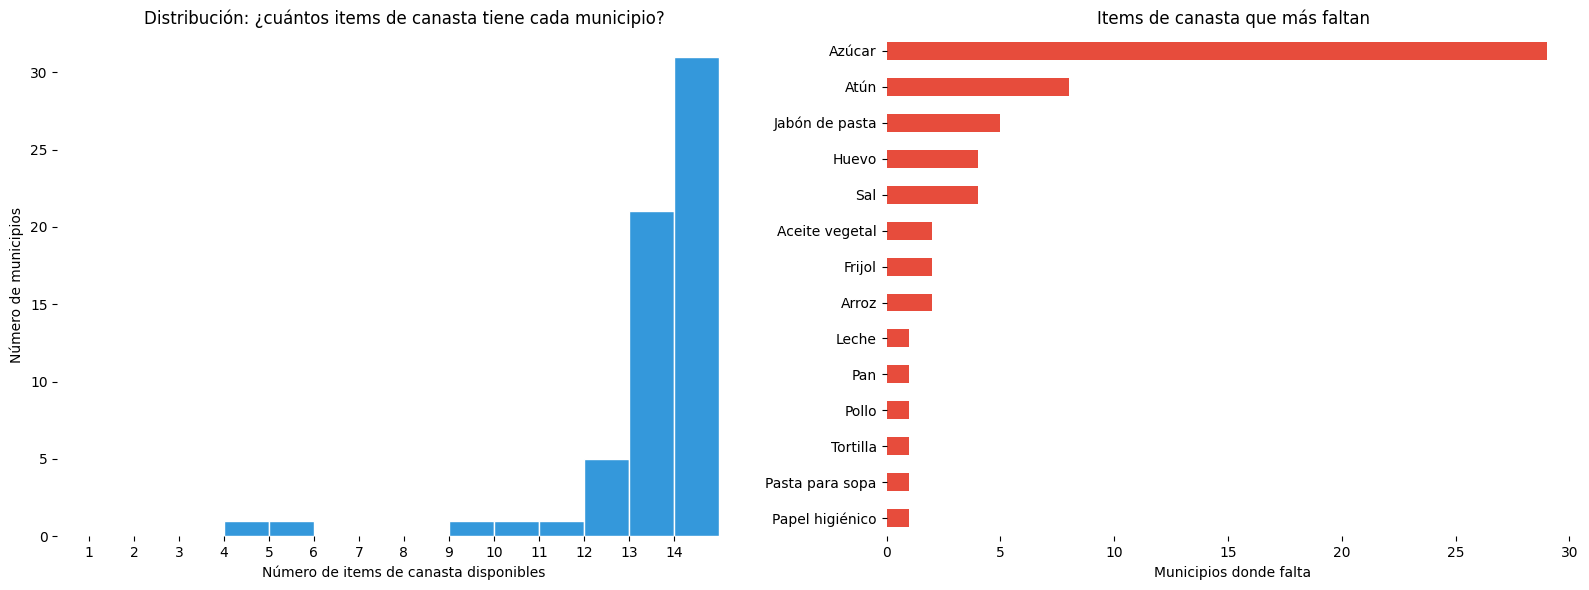

In [18]:
# Gráfica: distribución de cobertura
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histograma de items por municipio
ax1 = axes[0]
muni_canasta['n_items'].hist(bins=range(1, n_total_items+2), ax=ax1, color='#3498db', edgecolor='white')
ax1.set_xlabel('Número de items de canasta disponibles')
ax1.set_ylabel('Número de municipios')
ax1.set_title('Distribución: ¿cuántos items de canasta tiene cada municipio?')
ax1.set_xticks(range(1, n_total_items+1))

# Items que más faltan
ax2 = axes[1]
faltantes_df = pd.Series(items_faltantes_counter).sort_values(ascending=True)
faltantes_df.plot(kind='barh', ax=ax2, color='#e74c3c')
ax2.set_xlabel('Municipios donde falta')
ax2.set_title('Items de canasta que más faltan')

for ax in axes:
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.tight_layout()
plt.show()

In [19]:
# Generar el catálogo que usará el frontend
# Solo municipios que tengan al menos X items de canasta

UMBRAL_MINIMO = 5  # ajustar según resultados

municipios_validos = muni_canasta[muni_canasta['n_items'] >= UMBRAL_MINIMO]

catalogo_qqp = {}
for _, row in municipios_validos.iterrows():
    estado = row['estado']
    if estado not in catalogo_qqp:
        catalogo_qqp[estado] = []
    catalogo_qqp[estado].append({
        'municipio': row['municipio'],
        'n_items': row['n_items'],
        'cobertura_pct': row['cobertura_pct'],
    })

# Ordenar
for estado in catalogo_qqp:
    catalogo_qqp[estado] = sorted(catalogo_qqp[estado], key=lambda x: x['municipio'])

print(f"Catálogo QQP para frontend:")
print(f"  Estados: {len(catalogo_qqp)}")
print(f"  Municipios: {sum(len(v) for v in catalogo_qqp.values())}")
print(f"  Umbral: ≥{UMBRAL_MINIMO} items de canasta")

# Preview
for estado, munis in sorted(catalogo_qqp.items())[:5]:
    print(f"\n  📍 {estado} ({len(munis)} municipios)")
    for m in munis[:3]:
        print(f"     • {m['municipio']} — {m['n_items']}/{n_total_items} items")
    if len(munis) > 3:
        print(f"     ... y {len(munis)-3} más")

Catálogo QQP para frontend:
  Estados: 30
  Municipios: 61
  Umbral: ≥5 items de canasta

  📍 Aguascalientes (1 municipios)
     • Aguascalientes — 14/14 items

  📍 Baja California (1 municipios)
     • Tijuana — 13/14 items

  📍 Baja California Sur (1 municipios)
     • La Paz — 14/14 items

  📍 Campeche (1 municipios)
     • Campeche — 14/14 items

  📍 Chiapas (1 municipios)
     • Tuxtla Gutiérrez — 14/14 items


In [20]:
# ¿Qué está pasando con Azúcar?
# Veamos si el problema es el filtro de presentación o el producto en sí

mask_azucar_producto = df_super['producto'].isin(['Azúcar'])
azucar_todo = df_super[mask_azucar_producto]

print(f"Registros totales de 'Azúcar' (sin filtro de presentación): {len(azucar_todo)}")
print(f"Estados: {azucar_todo['estado'].nunique()}")
print(f"Municipios: {azucar_todo.groupby(['estado','municipio']).ngroups}")

print(f"\nPresentaciones de Azúcar en el dataset:")
for pres, count in azucar_todo['presentacion'].value_counts().items():
    n_est = azucar_todo[azucar_todo['presentacion'] == pres]['estado'].nunique()
    print(f"  {pres:<50} | {count:>4} registros | {n_est:>2} estados")

Registros totales de 'Azúcar' (sin filtro de presentación): 2364
Estados: 30
Municipios: 62

Presentaciones de Azúcar en el dataset:
  Bolsa Plástico 900 Gr. Estándar                    | 1219 registros | 30 estados
  Bolsa Plástico 2 Kg. Estándar o Morena             |  316 registros | 28 estados
  Bolsa 500 Gr. Mascabado                            |  210 registros | 26 estados
  Bolsa Plástico 2 Kg. Refinada                      |  161 registros | 26 estados
  Bolsa Plástico 2 Kg. Estándar                      |  144 registros | 24 estados
  Caja 200 Gr. (50 Sobres de 4 Gr. C/u). Mascabado   |  115 registros | 23 estados
  1 Kg. Granel. Estándar Morena                      |   65 registros | 18 estados
  Bolsa Plástico 1 Kg. Estándar                      |   35 registros |  6 estados
  Bolsa Plástico 900 Gr. Refinada                    |   28 registros | 15 estados
  Bolsa Plástico 1.8 Kg. Estándar                    |   26 registros | 16 estados
  Bolsa Plástico 900 Gr. Estándar o M

In [21]:
# Comparar: Azúcar con presentación "1 Kg" vs "2 Kg" vs "900 Gr"
for pres_filter in ['1 Kg', '2 Kg', '900 Gr', '500 Gr', 'Bolsa']:
    mask = azucar_todo['presentacion'].str.contains(pres_filter, case=False, na=False)
    sub = azucar_todo[mask]
    print(f"\n  Azúcar [{pres_filter}]: {len(sub)} registros | {sub['estado'].nunique()} estados | "
          f"{sub.groupby(['estado','municipio']).ngroups} municipios")


  Azúcar [1 Kg]: 114 registros | 21 estados | 33 municipios

  Azúcar [2 Kg]: 622 registros | 28 estados | 56 municipios

  Azúcar [900 Gr]: 1261 registros | 30 estados | 60 municipios

  Azúcar [500 Gr]: 210 registros | 26 estados | 52 municipios

  Azúcar [Bolsa]: 2179 registros | 30 estados | 61 municipios


In [22]:
# Atún — falta en 8 municipios (13%)
# ¿Es por la presentación "Lata 130 Gr"?
mask_atun = df_super['producto'].isin(['Atún'])
atun_todo = df_super[mask_atun]
print(f"Atún sin filtro: {atun_todo.groupby(['estado','municipio']).ngroups} municipios")

for pres_filter in ['Lata 130 Gr', 'Lata 140 Gr', 'Bolsa', 'Lata']:
    mask = atun_todo['presentacion'].str.contains(pres_filter, case=False, na=False)
    sub = atun_todo[mask]
    print(f"  Atún [{pres_filter}]: {sub.groupby(['estado','municipio']).ngroups} municipios")

Atún sin filtro: 62 municipios
  Atún [Lata 130 Gr]: 54 municipios
  Atún [Lata 140 Gr]: 61 municipios
  Atún [Bolsa]: 59 municipios
  Atún [Lata]: 62 municipios


In [23]:
# Jabón de pasta — falta en 5 municipios (8%)
mask_jabon = df_super['producto'].isin(['Jabón de Pasta'])
jabon_todo = df_super[mask_jabon]
print(f"\nJabón sin filtro: {jabon_todo.groupby(['estado','municipio']).ngroups} municipios")

for pres_filter in ['200 Gr', '400 Gr', 'Barra']:
    mask = jabon_todo['presentacion'].str.contains(pres_filter, case=False, na=False)
    sub = jabon_todo[mask]
    print(f"  Jabón [{pres_filter}]: {sub.groupby(['estado','municipio']).ngroups} municipios")


Jabón sin filtro: 57 municipios
  Jabón [200 Gr]: 57 municipios
  Jabón [400 Gr]: 57 municipios
  Jabón [Barra]: 57 municipios


In [24]:
# La canasta ahora es simplemente un mapeo nombre → productos del dataset
CANASTA_V3 = {
    'Aceite':           ['Aceite'],
    'Arroz':            ['Arroz'],
    'Frijol':           ['Frijol', 'Frijoles'],
    'Azúcar':           ['Azúcar'],
    'Huevo':            ['Huevo'],
    'Leche':            ['Leche Ultrapasteurizada', 'Leche Condensada', 
                         'Leche Evaporada', 'Leche en Polvo'],
    'Pan':              ['Pan Blanco Bolillo', 'Pan de Caja', 
                         'Pan Dulce', 'Pastellios y Pan Dulce Empaquetado'],
    'Tortilla':         ['Tortilla de Maíz'],
    'Pollo':            ['Carne Pollo'],
    'Atún':             ['Atún'],
    'Jabón de pasta':   ['Jabón de Pasta'],
    'Papel higiénico':  ['Papel Higiénico'],
    'Pasta para sopa':  ['Pasta para Sopa'],
    'Sal':              ['Sal Molida de Mesa'],
}

In [25]:
# Para cada item de canasta, mapear su árbol completo
for item_name, productos in CANASTA_V3.items():
    mask = df_super['producto'].isin(productos)
    subset = df_super[mask]
    
    print(f"\n{'='*70}")
    print(f"🛒 {item_name} — {len(subset):,} registros | "
          f"{subset['estado'].nunique()} estados | "
          f"{subset.groupby(['estado','municipio']).ngroups} municipios")
    print(f"{'='*70}")
    
    # Árbol: producto → presentación → marcas
    for producto in sorted(subset['producto'].unique()):
        sub_prod = subset[subset['producto'] == producto]
        print(f"\n  📦 {producto} ({len(sub_prod):,} registros)")
        
        pres_stats = (
            sub_prod.groupby('presentacion')
            .agg(
                n_registros=('precio', 'count'),
                n_estados=('estado', 'nunique'),
                n_municipios=('municipio', 'nunique'),
                n_marcas=('marca', 'nunique'),
                precio_min=('precio', 'min'),
                precio_max=('precio', 'max'),
                marcas=('marca', lambda x: ', '.join(sorted(x.unique())[:3]))
            )
            .sort_values('n_registros', ascending=False)
        )
        
        for pres, row in pres_stats.iterrows():
            cobertura = "🟢" if row['n_estados'] >= 20 else "🟡" if row['n_estados'] >= 10 else "🔴"
            print(f"    {cobertura} {pres}")
            print(f"       {row['n_registros']:>4} reg | {row['n_estados']:>2} est | "
                  f"{row['n_municipios']:>2} mun | "
                  f"${row['precio_min']:.2f}-${row['precio_max']:.2f} | "
                  f"Marcas: {row['marcas']}")


🛒 Aceite — 3,046 registros | 30 estados | 62 municipios

  📦 Aceite (3,046 registros)
    🟢 Botella 850 Ml. Vegetal
        565 reg | 30 est | 58 mun | $26.50-$39.90 | Marcas: Ave, Gran Tradición, Ke Precio
    🟢 Botella 946 Ml. Soya
        551 reg | 30 est | 56 mun | $35.00-$55.00 | Marcas: Great Value, Nutrioli
    🟢 Botella 1 Lt. Vegetal
        374 reg | 29 est | 60 mun | $30.00-$67.00 | Marcas: 1_2_3, Cristal
    🟢 Botella 946 Ml. Canola
        336 reg | 30 est | 51 mun | $32.00-$50.90 | Marcas: Canoil
    🟢 Botella 850 Ml. Vegetal. Sabor Mantequilla
        311 reg | 29 est | 58 mun | $34.90-$48.90 | Marcas: Sabrosano
    🟢 Botella 825 Ml. Cártamo
        293 reg | 29 est | 58 mun | $60.00-$86.90 | Marcas: Oleico
    🟢 Botella 800 Ml. Vegetal
        198 reg | 28 est | 50 mun | $25.00-$33.00 | Marcas: Aurrera, Chedraui, Gran Tradición
    🟢 Botella 850 Ml. Soya
        158 reg | 29 est | 50 mun | $36.50-$49.90 | Marcas: Nutrioli
    🟢 Botella 840 Ml. Canola
         97 reg | 2

In [27]:
# Para un municipio ejemplo, ¿qué ve el usuario?
def preview_municipio(df, estado, municipio, canasta):
    """Simula lo que vería el usuario en el dashboard"""
    mask_loc = (df['estado'] == estado) & (df['municipio'] == municipio)
    df_local = df[mask_loc]
    
    print(f"\n{'#'*70}")
    print(f"  PREVIEW: {municipio}, {estado}")
    print(f"  {len(df_local):,} registros | {df_local['cadena_comercial'].nunique()} cadenas")
    print(f"{'#'*70}")
    
    for item_name, productos in canasta.items():
        mask = df_local['producto'].isin(productos)
        subset = df_local[mask]
        
        if len(subset) == 0:
            print(f"\n  ❌ {item_name}: Sin datos")
            continue
        
        n_opciones = subset.groupby(['producto', 'presentacion', 'marca']).ngroups
        mas_barato = subset.nsmallest(1, 'precio').iloc[0]
        mas_caro = subset.nlargest(1, 'precio').iloc[0]
        
        print(f"\n  🛒 {item_name} — {n_opciones} opciones")
        print(f"     💚 Más barato: ${mas_barato['precio']:.2f} | "
              f"{mas_barato['marca']} | {mas_barato['presentacion']} | "
              f"{mas_barato['cadena_comercial']}")
        print(f"     🔴 Más caro:   ${mas_caro['precio']:.2f} | "
              f"{mas_caro['marca']} | {mas_caro['presentacion']} | "
              f"{mas_caro['cadena_comercial']}")
        
        # Presentaciones disponibles
        pres = subset.groupby('presentacion').agg(
            precio_min=('precio', 'min'),
            n_cadenas=('cadena_comercial', 'nunique')
        ).sort_values('precio_min')
        
        for p, r in pres.iterrows():
            print(f"       • {p} — desde ${r['precio_min']:.2f} ({r['n_cadenas']} cadenas)")

# Probar con distintos municipios
preview_municipio(df_super, 'Ciudad de Mexico', 'Benito Juárez', CANASTA_V3)



######################################################################
  PREVIEW: Benito Juárez, Ciudad de Mexico
  8,457 registros | 4 cadenas
######################################################################

  🛒 Aceite — 12 opciones
     💚 Más barato: $28.70 | Ke Precio | Botella 850 Ml. Vegetal | La Comer
     🔴 Más caro:   $80.00 | Oleico | Botella 825 Ml. Cártamo | La Comer
       • Botella 850 Ml. Vegetal — desde $28.70 (3.0 cadenas)
       • Botella 800 Ml. Vegetal — desde $30.00 (1.0 cadenas)
       • Botella 946 Ml. Soya — desde $38.00 (1.0 cadenas)
       • Botella 850 Ml. Vegetal. Sabor Mantequilla — desde $39.00 (2.0 cadenas)
       • Botella 1 Lt. Vegetal — desde $39.90 (4.0 cadenas)
       • Botella 850 Ml. Soya — desde $42.50 (2.0 cadenas)
       • Botella 840 Ml. Canola — desde $57.50 (1.0 cadenas)
       • Botella 765 Ml. Maíz — desde $58.00 (2.0 cadenas)
       • Botella 825 Ml. Cártamo — desde $68.00 (3.0 cadenas)

  🛒 Arroz — 15 opciones
     💚 Más barato: $1

In [28]:
preview_municipio(df_super, 'Sonora', 'Hermosillo', CANASTA_V3)


######################################################################
  PREVIEW: Hermosillo, Sonora
  5,463 registros | 6 cadenas
######################################################################

  🛒 Aceite — 14 opciones
     💚 Más barato: $26.90 | More Value | Botella 850 Ml. Vegetal | Ley
     🔴 Más caro:   $71.50 | Oleico | Botella 825 Ml. Cártamo | Hipermercado Soriana
       • Botella 850 Ml. Vegetal — desde $26.90 (2.0 cadenas)
       • Botella 800 Ml. Vegetal — desde $29.90 (2.0 cadenas)
       • Botella 946 Ml. Canola — desde $34.90 (5.0 cadenas)
       • Botella 850 Ml. Vegetal. Sabor Mantequilla — desde $35.90 (3.0 cadenas)
       • Botella 946 Ml. Soya — desde $37.00 (2.0 cadenas)
       • Botella 850 Ml. Soya — desde $38.90 (3.0 cadenas)
       • Botella 1 Lt. Vegetal — desde $39.90 (3.0 cadenas)
       • Botella 840 Ml. Canola — desde $45.00 (1.0 cadenas)
       • Botella 825 Ml. Cártamo — desde $61.90 (4.0 cadenas)
       • Botella 765 Ml. Maíz — desde $62.00 (1.0

In [29]:
preview_municipio(df_super, 'Guerrero', 'Acapulco de Juárez', CANASTA_V3)  # municipio con pocos datos



######################################################################
  PREVIEW: Acapulco de Juárez, Guerrero
  2,372 registros | 4 cadenas
######################################################################

  🛒 Aceite — 16 opciones
     💚 Más barato: $28.00 | Ave | Botella 850 Ml. Vegetal | Chedraui
     🔴 Más caro:   $70.50 | Oleico | Botella 825 Ml. Cártamo | Hipermercado Soriana
       • Botella 800 Ml. Vegetal — desde $28.00 (3.0 cadenas)
       • Botella 850 Ml. Vegetal — desde $28.00 (4.0 cadenas)
       • Botella 850 Ml. Vegetal. Sabor Mantequilla — desde $35.00 (4.0 cadenas)
       • Botella 946 Ml. Canola — desde $35.00 (4.0 cadenas)
       • Botella 1 Lt. Vegetal — desde $36.00 (4.0 cadenas)
       • Botella 875 Ml. Soya — desde $36.50 (1.0 cadenas)
       • Botella 946 Ml. Soya — desde $37.00 (2.0 cadenas)
       • Botella 850 Ml. Soya — desde $42.00 (2.0 cadenas)
       • Botella 840 Ml. Canola — desde $56.00 (1.0 cadenas)
       • Botella 765 Ml. Maíz — desde $62.00

In [30]:
# ¿Cómo se ve el JSON que alimentaría al frontend?
# Esto es el "contrato" entre backend y frontend

def generar_estructura_ui(df, estado, municipio, canasta):
    """
    Genera la estructura que el endpoint /api/v1/qqp/canasta devolvería.
    El frontend consume esto para armar las visualizaciones.
    """
    mask_loc = (df['estado'] == estado) & (df['municipio'] == municipio)
    df_local = df[mask_loc]
    
    resultado = {
        'estado': estado,
        'municipio': municipio,
        'n_cadenas': int(df_local['cadena_comercial'].nunique()),
        'items': {}
    }
    
    costo_minimo_total = 0
    
    for item_name, productos in canasta.items():
        mask = df_local['producto'].isin(productos)
        subset = df_local[mask]
        
        if len(subset) == 0:
            resultado['items'][item_name] = None
            continue
        
        # Agrupar por presentación
        presentaciones = {}
        for pres in subset['presentacion'].unique():
            sub_pres = subset[subset['presentacion'] == pres]
            
            opciones = []
            for _, row in sub_pres.sort_values('precio').iterrows():
                opciones.append({
                    'precio': float(row['precio']),
                    'marca': row['marca'],
                    'cadena': row['cadena_comercial'],
                    'tienda': row['nombre_comercial'],
                })
            
            presentaciones[pres] = {
                'n_opciones': len(opciones),
                'precio_min': opciones[0]['precio'],
                'precio_max': opciones[-1]['precio'],
                'opciones': opciones,
            }
        
        # El más barato de todas las presentaciones
        mas_barato_global = subset.nsmallest(1, 'precio').iloc[0]
        
        resultado['items'][item_name] = {
            'producto': mas_barato_global['producto'],
            'precio_min_global': float(mas_barato_global['precio']),
            'marca_min': mas_barato_global['marca'],
            'cadena_min': mas_barato_global['cadena_comercial'],
            'presentacion_min': mas_barato_global['presentacion'],
            'n_presentaciones': len(presentaciones),
            'n_opciones_total': len(subset),
            'presentaciones': presentaciones,
        }
        
        costo_minimo_total += float(mas_barato_global['precio'])
    
    resultado['costo_minimo_canasta'] = round(costo_minimo_total, 2)
    resultado['items_disponibles'] = sum(1 for v in resultado['items'].values() if v is not None)
    resultado['items_total'] = len(canasta)
    
    return resultado

# Test
import json
estructura = generar_estructura_ui(df_super, 'Sonora', 'Hermosillo', CANASTA_V3)
print(json.dumps(estructura, indent=2, ensure_ascii=False, default=str)[:3000])

{
  "estado": "Sonora",
  "municipio": "Hermosillo",
  "n_cadenas": 6,
  "items": {
    "Aceite": {
      "producto": "Aceite",
      "precio_min_global": 26.9,
      "marca_min": "More Value",
      "cadena_min": "Ley",
      "presentacion_min": "Botella 850 Ml. Vegetal",
      "n_presentaciones": 10,
      "n_opciones_total": 60,
      "presentaciones": {
        "Botella 850 Ml. Vegetal": {
          "n_opciones": 8,
          "precio_min": 26.9,
          "precio_max": 32.9,
          "opciones": [
            {
              "precio": 26.9,
              "marca": "More Value",
              "cadena": "Ley",
              "tienda": "Ley Sucursal Vado del Rio"
            },
            {
              "precio": 29.5,
              "marca": "Precíssimo",
              "cadena": "Hipermercado Soriana",
              "tienda": "Soriana Hiper Sucursal Vado del Rio"
            },
            {
              "precio": 29.5,
              "marca": "Precíssimo",
              "cadena": "H